In [1]:
import huxt 
import huxt_inputs as HI
import huxt_analysis as HA

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from astropy.time import Time

/opt/miniconda3/envs/huxt/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

In [3]:
crlist = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/input/met.csv")

In [4]:
# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5','Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)

Files Downloaded: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.72file/s]
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_5354/3539623498.py:30: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()
Files Downloaded: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.75file/s]


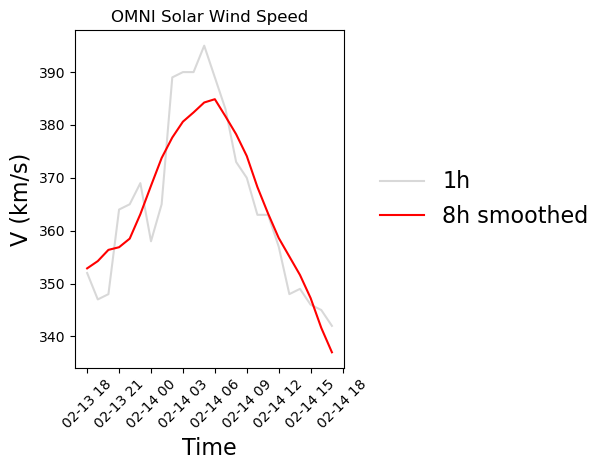

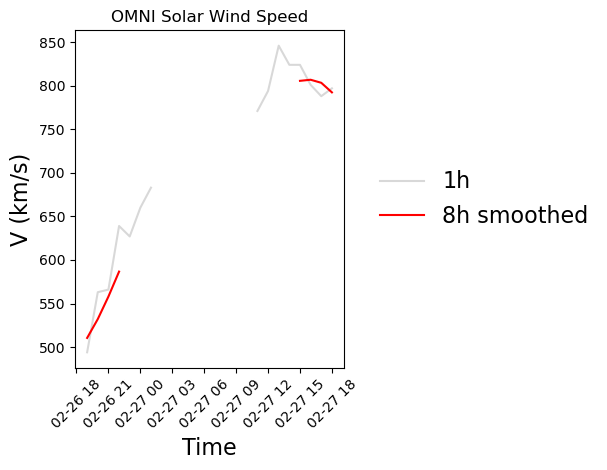

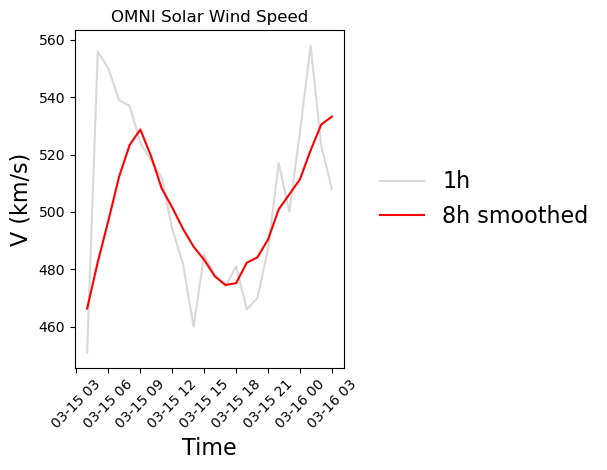

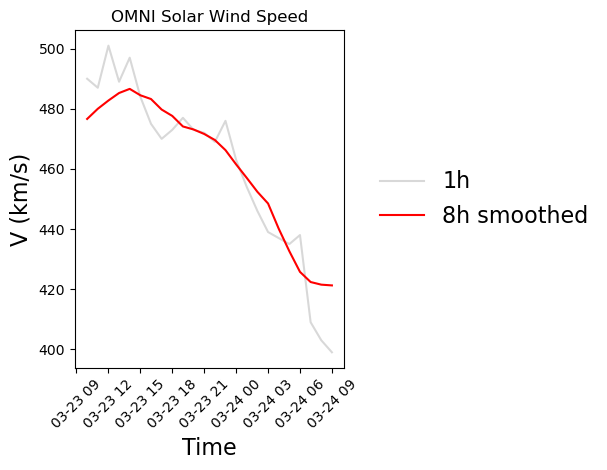

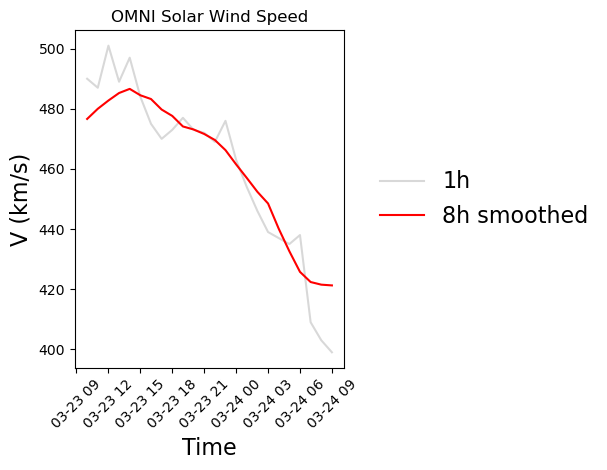

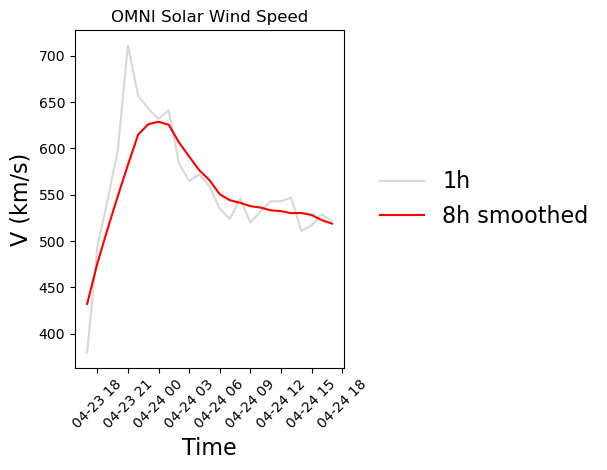

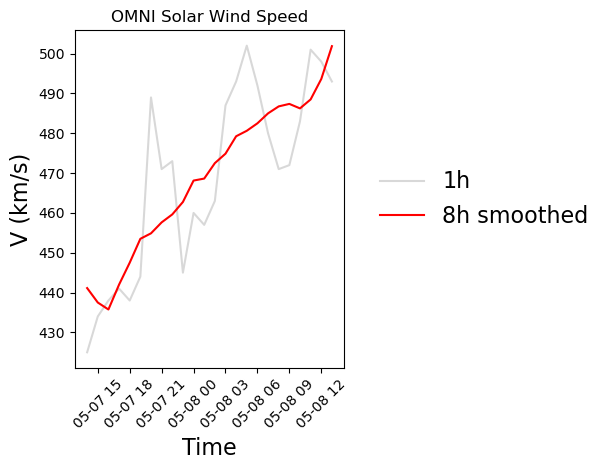

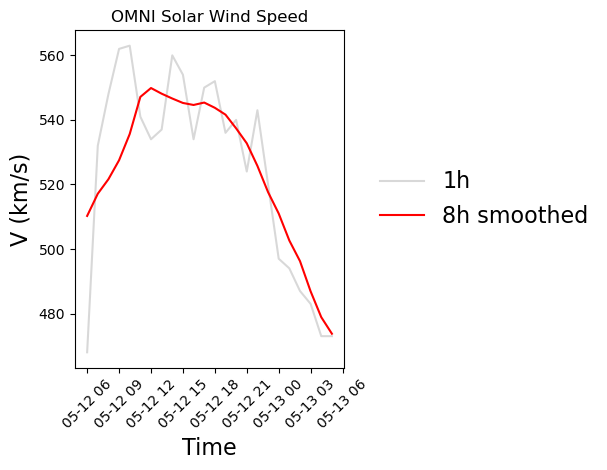

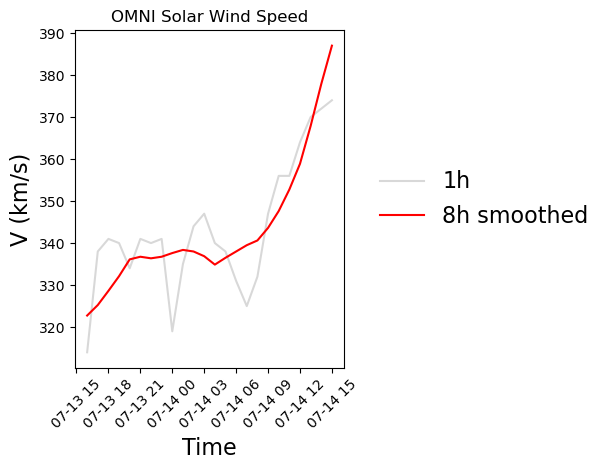

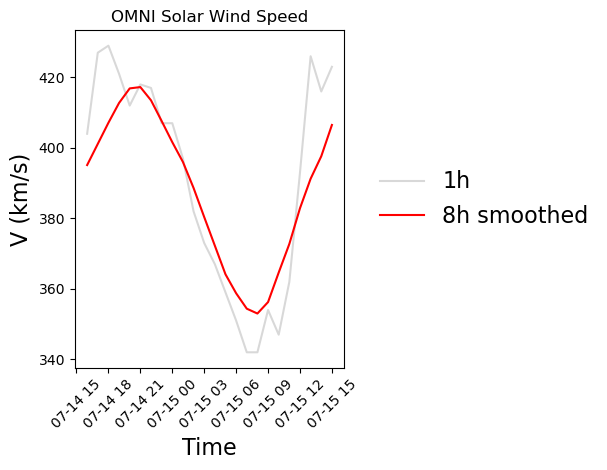

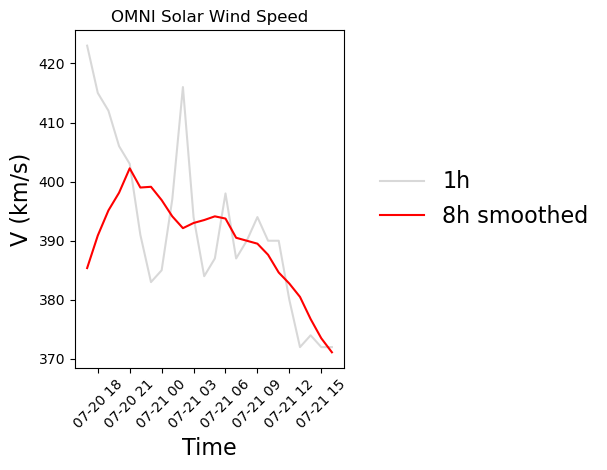

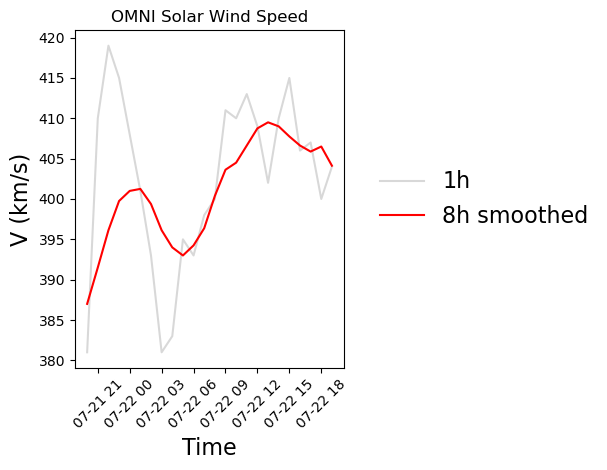

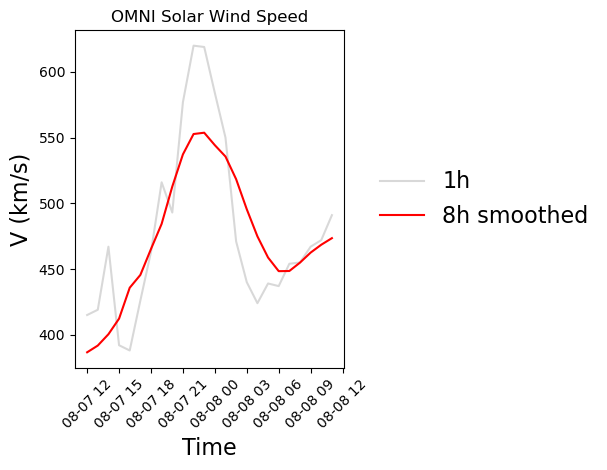

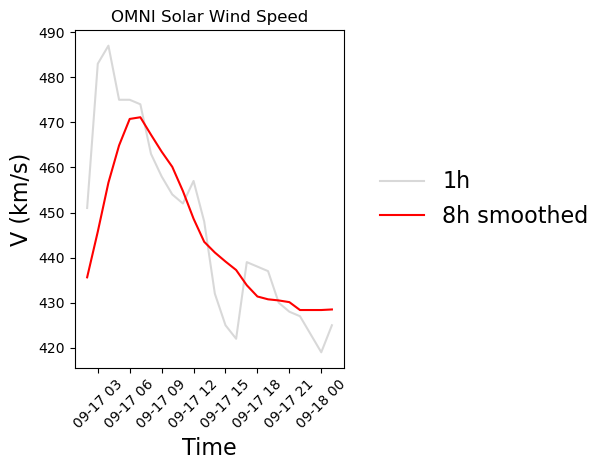

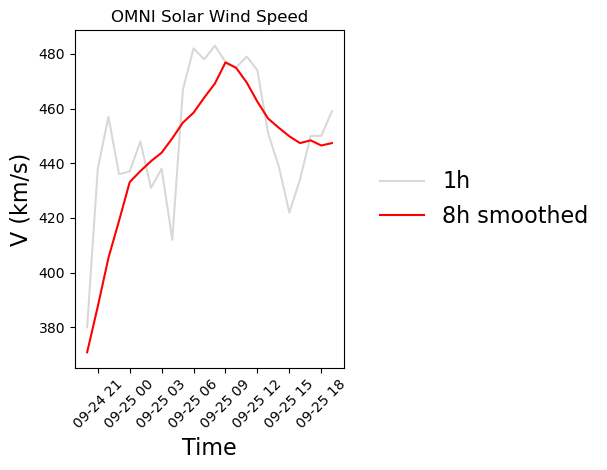

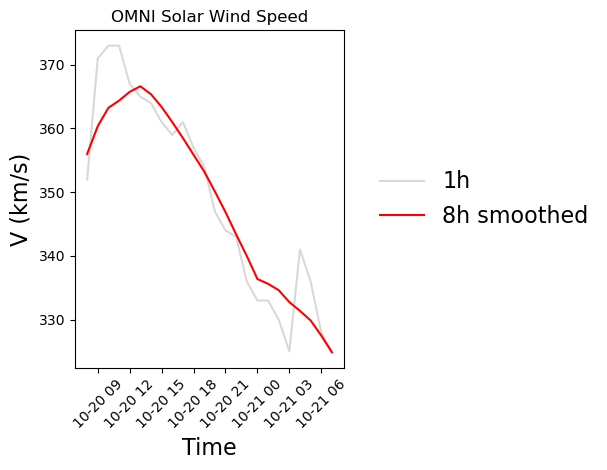

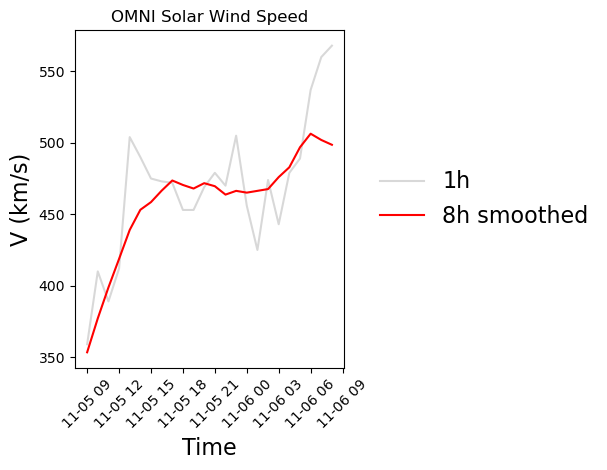

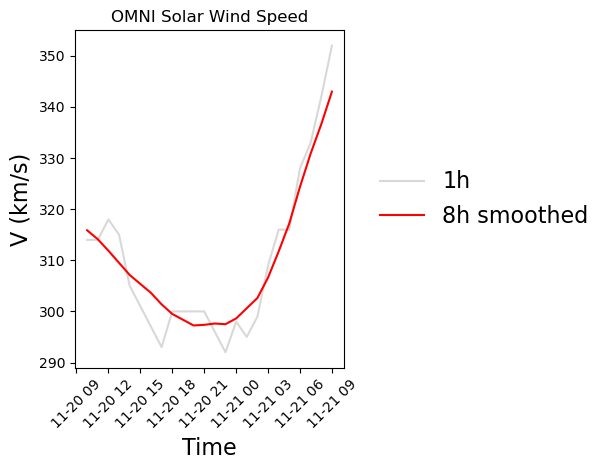

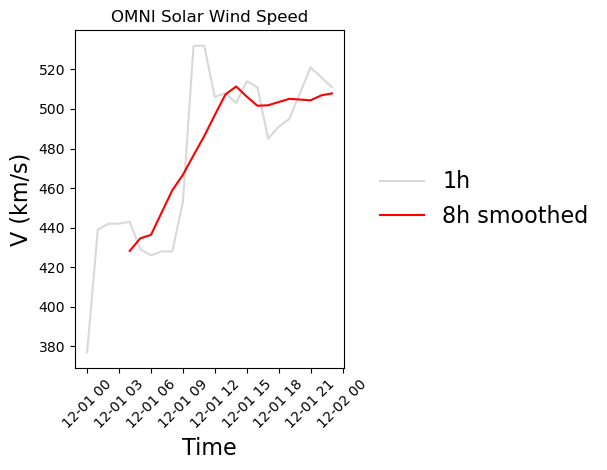

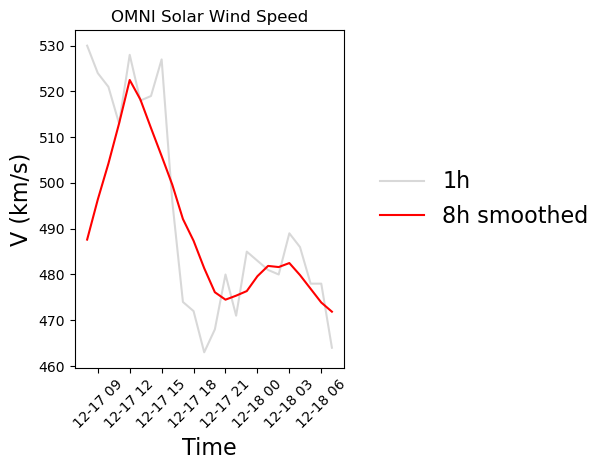

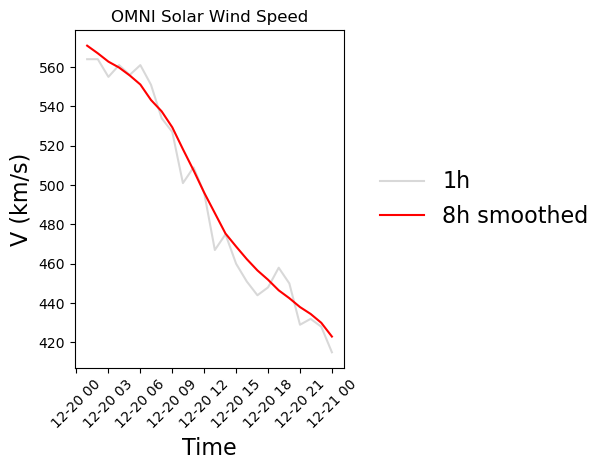

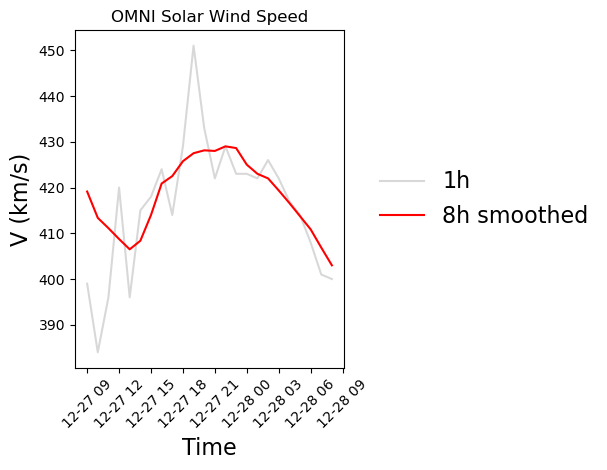

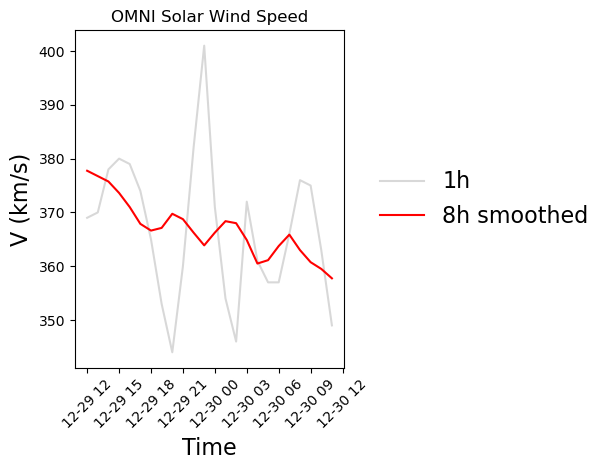

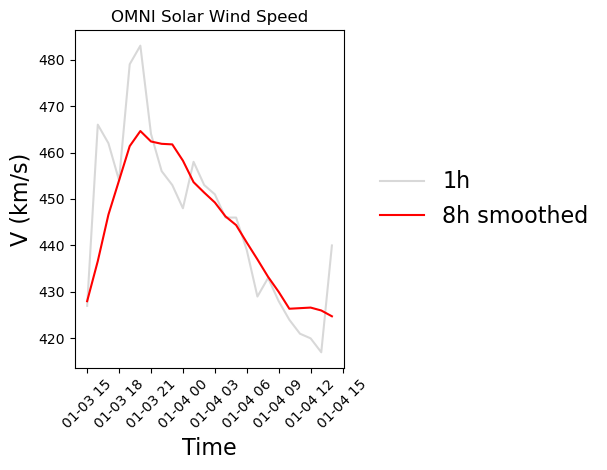

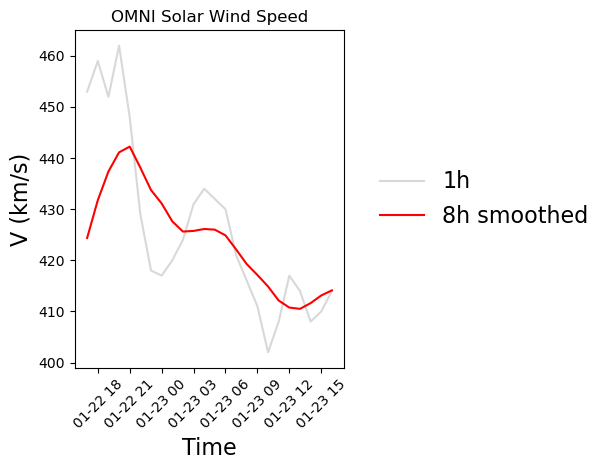

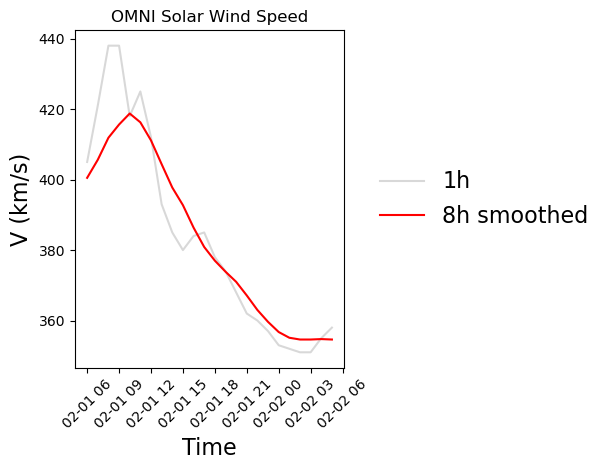

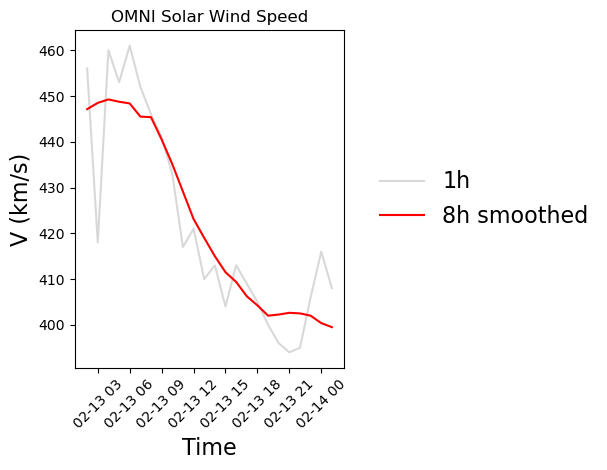

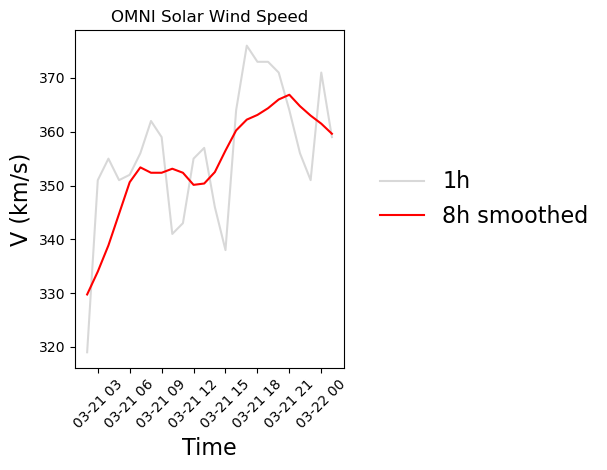

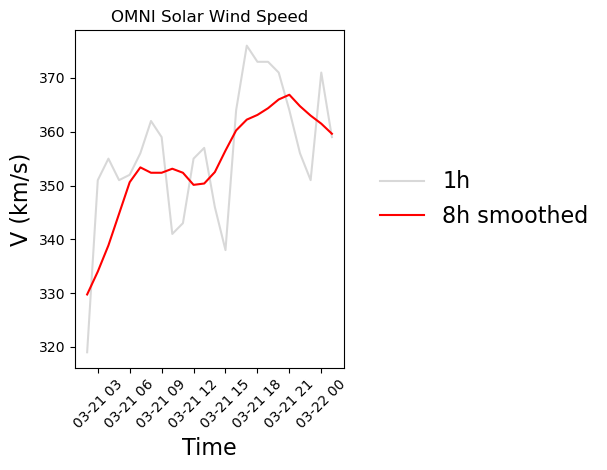

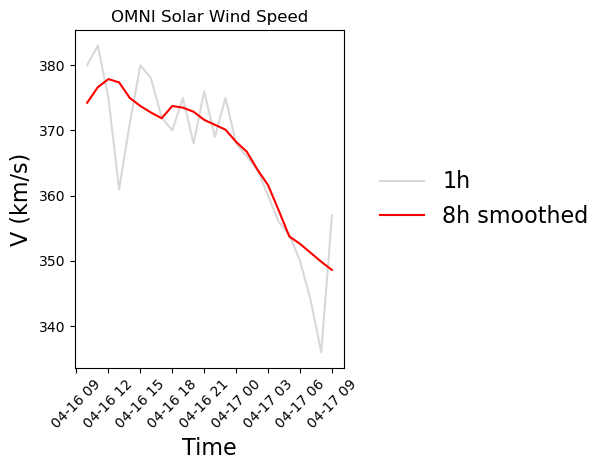

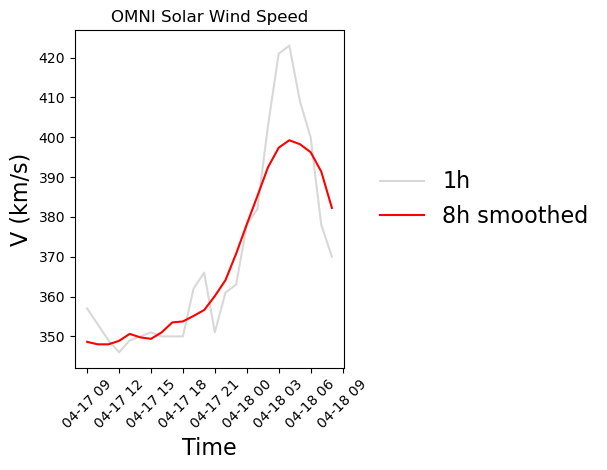

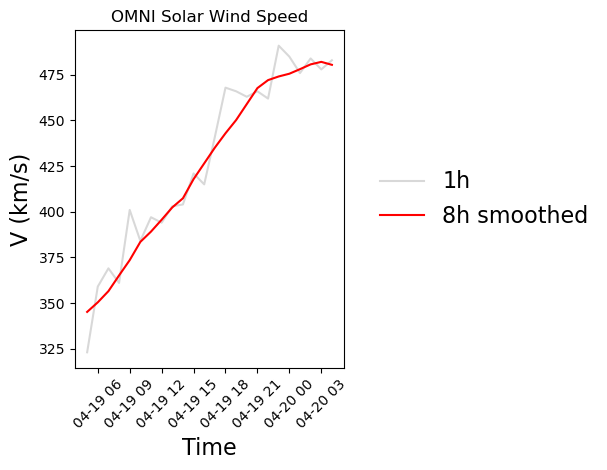

In [14]:
# Pre-initialise column to store arrival speed values
V_max = []
V_max_smooth = []

# Loop analysis for all CMEs
for _, onecme in crlist.iterrows():
    
    # get the omni data
    starttime = onecme['Disturbance_Time']
    endtime = starttime + timedelta(days=1)
    data = HI.get_omni(starttime, endtime)
    V_1h = data['V']
    V_smooth_8h = data['V'].rolling(8, center=True).mean()

    # smooth data over 3h and find maximum
    mask = (data['datetime'] >= starttime) & (data['datetime'] <= endtime)
    plotdata = data[mask]
    data_1h = V_1h[mask]
    data_8h = V_smooth_8h[mask]
    
    speed_1h = np.nan
    speed_1h = data_1h.max()
    V_max.append(speed_1h)
    speed_8h = np.nan
    speed_8h = data_8h.max()
    V_max_smooth.append(speed_8h)


    # plot the period of interest and save in figures folder
    fig, ax = plt.subplots() 
    ax.plot(plotdata['datetime'], data_1h, color='gray', alpha=0.3, label='1h') 
    ax.plot(plotdata['datetime'], data_8h, 'r', label='8h smoothed') 
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.legend(loc='center left',
        bbox_to_anchor=(1.1, 0.5),
        borderaxespad=0,
        frameon=False)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('V (km/s)')
    ax.set_title('OMNI Solar Wind Speed')
    
    filename = f"/Users/dven/repos/CME_pulse_duration/huxt/figures/OMNI_speeds/{onecme['Disturbance_Time']}.pdf"
    fig.tight_layout()
    fig.savefig(filename, format="pdf", bbox_inches="tight")    

In [15]:
# Save V_max into crlist and export as csv

crlist['V_max'] = V_max
crlist['V_max_smooth'] = V_max_smooth
crlist.to_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/input/(I)CMEs.csv", index=False)